# 5 — Bancada de exploração

Notebook de trabalho: a célula abaixo deixa tudo carregado e pronto. Diferente dos notebooks
1–4, aqui nada é definitivo — é onde testamos ideias antes de decidir o que vira análise.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

from src.utils import load_config
from src import antenna

CIDADE = "campinas"
config = load_config(CIDADE)
config["spatial"]["download_basemap"] = True

edges_antenna = pd.read_parquet(ROOT / config["data"]["edges_antenna_path"])
antennas = pd.read_parquet(ROOT / config["data"]["antennas_path"])

net   = antenna.build(edges_antenna, antennas, config)
nodes = net.nodes          # uma linha por região
flows = net.flows          # uma linha por par de regiões conectado
G     = net.G              # grafo não-direcionado ponderado
D     = net.D              # versão dirigida
B     = net.backbone       # backbone por filtro de disparidade

cm = antenna.build_contact_matrix(edges_antenna, nodes)   # matriz do paper
K, J = cm.K, cm.J

print(f"{net.n_antennas} regiões | {G.number_of_edges():,} fluxos | {nodes['n_users'].sum():,} moradores")
print(f"objetos prontos: nodes, flows, G, D, B, cm, K, J")

145 regiões | 5,817 fluxos | 25,176 moradores
objetos prontos: nodes, flows, G, D, B, cm, K, J


## Atalhos úteis

Mapa temático de qualquer coluna de `nodes` (usa as células de Voronoi):

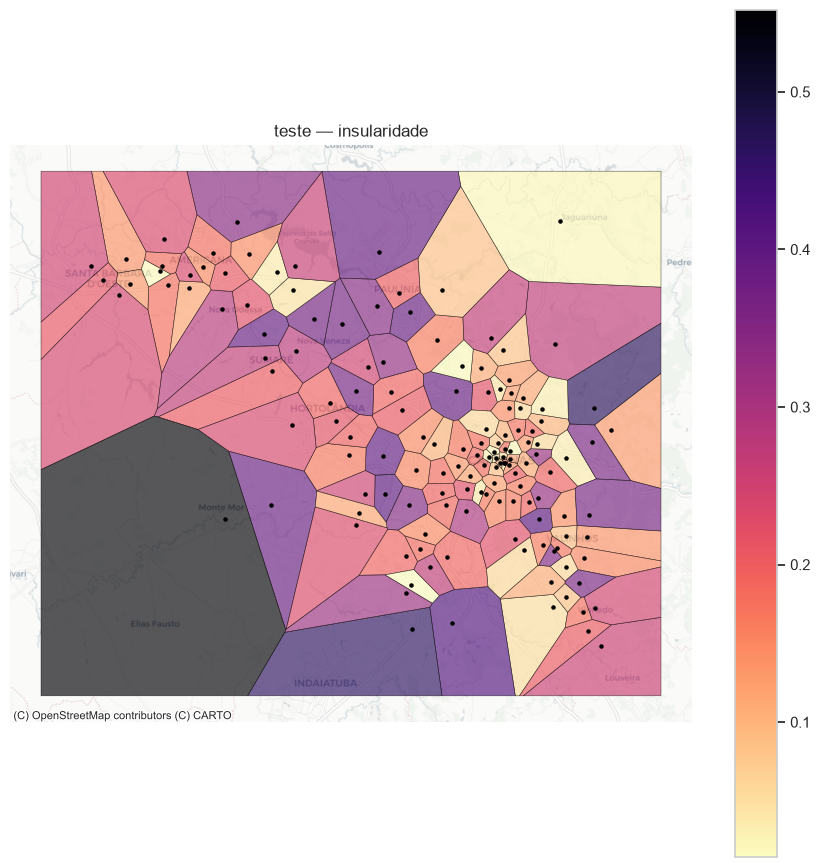

In [2]:
from src.pipeline.spatial import _build_gdf, _build_voronoi, _add_basemap

gdf = _build_gdf(nodes)
vor = _build_voronoi(gdf)


def mapa(coluna, titulo=None, cmap="viridis", categorico=False, centro=None, dados=None):
    """Pinta as regiões por uma coluna. `dados` permite passar uma Series indexada por antenna_id."""
    v = vor.copy()
    if dados is not None:
        v[coluna] = v["antenna_id"].map(dados)
    fig, ax = plt.subplots(figsize=(11, 11))
    kw = dict(column=coluna, cmap=cmap, legend=True, edgecolor="black",
              linewidth=0.4, alpha=0.65, ax=ax)
    if categorico:
        kw["categorical"] = True
    elif centro is not None:
        s = v[coluna].dropna()
        span = max(abs(s.min() - centro), abs(s.max() - centro))
        kw.update(vmin=centro - span, vmax=centro + span)
    v.plot(**kw)
    gdf.plot(ax=ax, color="black", markersize=5)
    _add_basemap(ax, config)
    ax.set_axis_off()
    ax.set_title(titulo or coluna)
    plt.show()


mapa("insularity", "teste — insularidade", cmap="magma_r")

## Espaço de trabalho

A partir daqui é livre.

In [3]:
nodes.head()

,antenna_id,residence_city,residence_quintile_state,residence_quintile_nation,lon,lat,n_users,calls_out,duration_out,calls_in,duration_in,calls_internal,duration_internal,calls_total,calls_external,insularity,net_balance,calls_per_user
0,22,Campinas,q5,q5,-47.04919,-22.93991,228,7550,10557.19,5914,11188.04,1919,3629.34,11545,9626,0.166219,0.121509,50.635965
1,52,Campinas,q4,q4,-47.01132,-22.80971,81,2347,5365.33,2010,3451.97,930,1145.17,3427,2497,0.271374,0.077347,42.308642
2,275,Campinas,q5,q5,-47.14177,-22.78256,117,3389,3833.74,3478,4619.79,1907,1830.03,4960,3053,0.384476,-0.012961,42.393162
3,312,Campinas,q1,q2,-47.15887,-22.84911,343,8687,17615.56,8666,17573.95,2826,3290.89,14527,11701,0.194534,0.001210,42.352770
4,321,Campinas,q5,q5,-47.07153,-22.84958,217,4934,7698.98,5091,7124.22,1796,2081.70,8229,6433,0.218253,-0.015661,37.921659


# Análises sobre J

Cinco leituras simples da matriz de conexão. Todas usam `J` — a fração dos pares possíveis de
usuários que está de fato conectada entre duas regiões — que já vem normalizada pelo tamanho das
regiões, então nada aqui é reflexo de "onde mora mais gente".

## Preliminar: macro-regiões

Várias figuras ficam mais legíveis com as antenas agrupadas. Reaproveitamos a divisão do notebook 2.

In [4]:
from networkx.algorithms.community import louvain_communities

comunidades = louvain_communities(G, weight="weight", seed=42)
macro = pd.Series({a: i for i, c in enumerate(comunidades) for a in c}, name="macro_region")
nodes["macro_region"] = nodes["antenna_id"].map(macro)

# ordem das antenas: agrupadas por macro-região
ordem = nodes.sort_values(["macro_region", "antenna_id"])["antenna_id"].to_numpy()
cortes = np.cumsum(nodes["macro_region"].value_counts().sort_index().to_numpy())[:-1]

nodes.groupby("macro_region").agg(antenas=("antenna_id", "size"),
                                  moradores=("n_users", "sum"))

,antenas,moradores
macro_region,,
0,54,7598
1,25,6661
2,27,6703
3,18,1622
4,21,2592


## 1. Como J se distribui

Antes de qualquer coisa, a ordem de grandeza: quão conectadas duas regiões são, de fato?

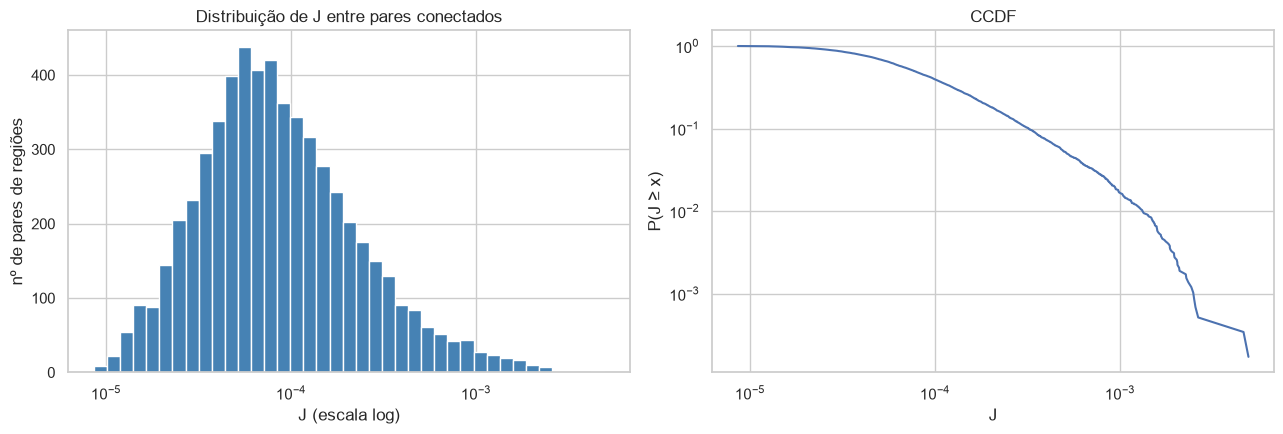

pares conectados: 5,817 de 10,440 possíveis (55.7%)
J: mediana 7.69e-05 | média 1.52e-04 | máximo 4.96e-03
o par mais denso conecta 0.50% dos seus pares possíveis


In [5]:
Jz = antenna.build_contact_matrix(edges_antenna, nodes, diagonal="zero").J
vals = Jz.to_numpy()[np.triu_indices(len(Jz), k=1)]
pos = vals[vals > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40), color="steelblue")
axes[0].set_xscale("log")
axes[0].set_xlabel("J (escala log)"); axes[0].set_ylabel("nº de pares de regiões")
axes[0].set_title("Distribuição de J entre pares conectados")

x = np.sort(pos)[::-1]
axes[1].loglog(x, np.arange(1, len(x) + 1) / len(x), "-")
axes[1].set_xlabel("J"); axes[1].set_ylabel("P(J ≥ x)")
axes[1].set_title("CCDF")
plt.tight_layout(); plt.show()

print(f"pares conectados: {len(pos):,} de {len(vals):,} possíveis ({len(pos)/len(vals):.1%})")
print(f"J: mediana {np.median(pos):.2e} | média {pos.mean():.2e} | máximo {pos.max():.2e}")
print(f"o par mais denso conecta {pos.max():.2%} dos seus pares possíveis")

Duas coisas para notar: mais da metade dos pares de regiões tem **algum** contato, mas o mais denso
liga menos de 1% dos pares possíveis. E a distribuição é de cauda longa — a maioria dos pares se
conecta muito pouco, alguns bem mais.

## 2. Matriz de correlação entre antenas

Cada linha de J é o **perfil de conexão** de uma antena: com quem ela fala e com que intensidade.
Correlacionar duas linhas responde: *estas duas regiões se relacionam com o resto da cidade de forma
parecida?*

É a ideia clássica de **equivalência estrutural** — duas regiões podem nem falar entre si e ainda
assim serem "equivalentes" por terem os mesmos parceiros. Note que é diferente de comunidade:
comunidade é quem fala **com quem**; equivalência é quem tem **o mesmo padrão**.

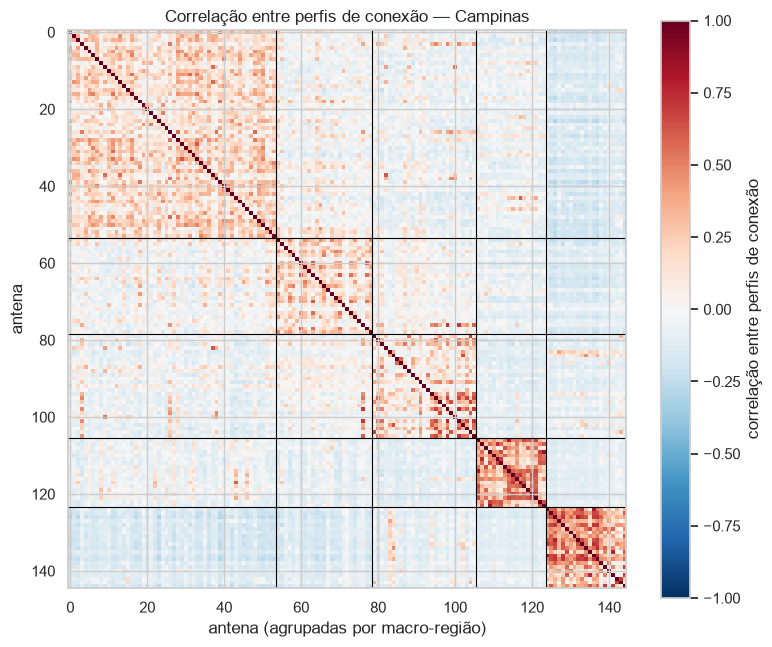

correlação: mediana -0.039 | mínima -0.315 | máxima 0.851


In [6]:
# perfis: linhas de J sem a diagonal (a auto-conexão distorceria a correlação)
perfis = Jz.reindex(index=ordem, columns=ordem)
C = pd.DataFrame(np.corrcoef(perfis.to_numpy()), index=ordem, columns=ordem)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(C.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
fig.colorbar(im, ax=ax, label="correlação entre perfis de conexão")
for c in cortes:                       # fronteiras das macro-regiões
    ax.axhline(c - 0.5, color="black", lw=0.8)
    ax.axvline(c - 0.5, color="black", lw=0.8)
ax.set_xlabel("antena (agrupadas por macro-região)"); ax.set_ylabel("antena")
ax.set_title("Correlação entre perfis de conexão — " + config["city_name"])
plt.show()

fora = ~np.eye(len(C), dtype=bool)
print(f"correlação: mediana {np.median(C.to_numpy()[fora]):.3f} | "
      f"mínima {C.to_numpy()[fora].min():.3f} | máxima {C.to_numpy()[fora].max():.3f}")

Os quadrados ao longo da diagonal mostram se as macro-regiões também são estruturalmente
equivalentes — se as antenas de uma mesma macro-região têm perfis parecidos, e não apenas se falam
muito entre si.

In [7]:
mr = nodes.set_index("antenna_id")["macro_region"].reindex(ordem).to_numpy()
mesma = mr[:, None] == mr[None, :]
print(f"correlação média dentro da mesma macro-região: {C.to_numpy()[mesma & fora].mean():.3f}")
print(f"correlação média entre macro-regiões distintas: {C.to_numpy()[~mesma].mean():.3f}")

li, mi = np.triu_indices(len(C), k=1)
top = pd.DataFrame({"a": ordem[li], "b": ordem[mi], "correlacao": C.to_numpy()[li, mi]})
top = top.nlargest(10, "correlacao")
top["J_entre_elas"] = [Jz.loc[a, b] for a, b in zip(top["a"], top["b"])]
top["mesma_macro"] = [macro[a] == macro[b] for a, b in zip(top["a"], top["b"])]
top.round(5)

correlação média dentro da mesma macro-região: 0.200
correlação média entre macro-regiões distintas: -0.049


,a,b,correlacao,J_entre_elas,mesma_macro
9823,2514,8455,0.85102,0.00077,True
10241,404,5572,0.81636,0.00048,True
9706,331,4704,0.79839,0.00087,True
10274,702,4591,0.77753,0.00075,True
10400,5523,6910,0.76191,0.00164,True
9361,5979,7096,0.75059,0.00013,True
9740,835,3608,0.74934,0.00000,True
10387,5101,6002,0.74550,0.00094,True
10376,4987,5572,0.73008,0.00130,True
10404,5572,6002,0.72995,0.00060,True


## 3. J cai com a distância?

O notebook 3 mostrou o decaimento usando volume de chamadas, e precisou de um modelo de gravidade
para separar o efeito do tamanho das regiões. Com J o tamanho **já está controlado** — dá para olhar
o decaimento direto.

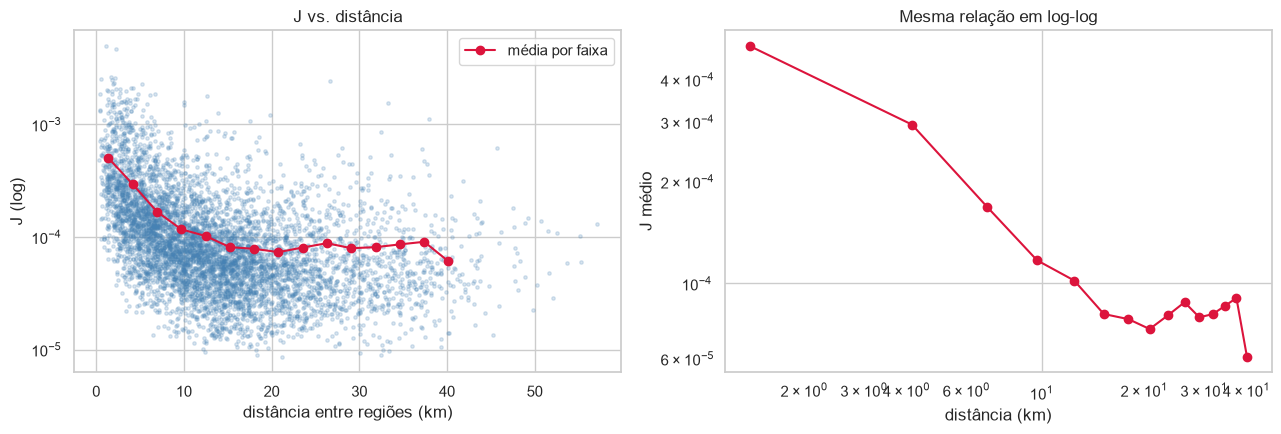

ajuste direto: J ~ d^-0.67
(com q_calls, o modelo de gravidade dava d^-1.09 — mas só depois de descontar o tamanho)


In [8]:
f = flows[flows["J"] > 0].copy()
faixas = pd.cut(f["dist_km"], bins=np.linspace(0, f["dist_km"].quantile(0.99), 16))
por_faixa = f.groupby(faixas, observed=True).agg(J=("J", "mean"), n=("J", "size")).reset_index()
por_faixa["dist"] = por_faixa["dist_km"].apply(lambda i: i.mid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(f["dist_km"], f["J"], s=6, alpha=0.2, color="steelblue")
axes[0].plot(por_faixa["dist"], por_faixa["J"], "o-", color="crimson", label="média por faixa")
axes[0].set_yscale("log")
axes[0].set_xlabel("distância entre regiões (km)"); axes[0].set_ylabel("J (log)")
axes[0].set_title("J vs. distância"); axes[0].legend()

axes[1].loglog(por_faixa["dist"], por_faixa["J"], "o-", color="crimson")
axes[1].set_xlabel("distância (km)"); axes[1].set_ylabel("J médio")
axes[1].set_title("Mesma relação em log-log")
plt.tight_layout(); plt.show()

ok = f["dist_km"] > 0
b, a = np.polyfit(np.log(f.loc[ok, "dist_km"]), np.log(f.loc[ok, "J"]), 1)
print(f"ajuste direto: J ~ d^{b:.2f}")
print("(com q_calls, o modelo de gravidade dava d^-1.09 — mas só depois de descontar o tamanho)")

## 4. J entre estratos socioeconômicos

O `J` médio para cada par de quintis. Como J já é normalizado por tamanho, isso responde de forma
direta: *duas regiões de estratos diferentes se conectam menos do que duas do mesmo estrato?*

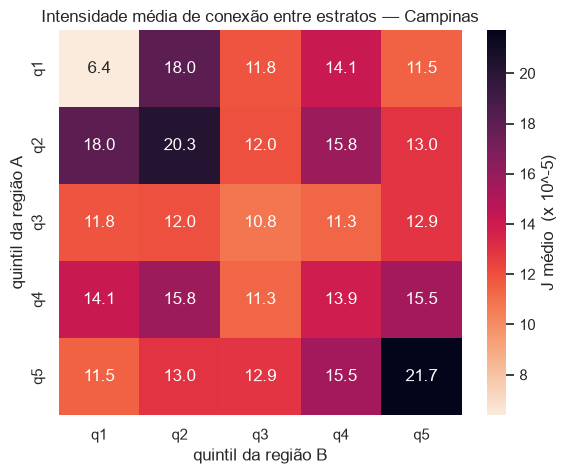

J médio dentro do mesmo quintil: 1.46e-04
J médio entre quintis distintos: 1.36e-04
razão: 1.08x


In [9]:
QUINTIS = ["q1", "q2", "q3", "q4", "q5"]
q = nodes.set_index("antenna_id")["residence_quintile_state"]

par = flows.copy()
par["qa"] = par["a"].map(q); par["qb"] = par["b"].map(q)
longo = pd.concat([
    par[["qa", "qb", "J"]],
    par[["qb", "qa", "J"]].rename(columns={"qb": "qa", "qa": "qb"}),
])
M = longo.pivot_table(index="qa", columns="qb", values="J", aggfunc="mean").reindex(
    index=QUINTIS, columns=QUINTIS)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(M * 1e5, annot=True, fmt=".1f", cmap="rocket_r", ax=ax,
            cbar_kws={"label": "J médio  (x 10^-5)"})
ax.set_xlabel("quintil da região B"); ax.set_ylabel("quintil da região A")
ax.set_title("Intensidade média de conexão entre estratos — " + config["city_name"])
plt.show()

diag = np.diagonal(M.to_numpy())
fora_d = M.to_numpy()[~np.eye(5, dtype=bool)]
print(f"J médio dentro do mesmo quintil: {np.nanmean(diag):.2e}")
print(f"J médio entre quintis distintos: {np.nanmean(fora_d):.2e}")
print(f"razão: {np.nanmean(diag)/np.nanmean(fora_d):.2f}x")

## 5. Conectividade de cada região, no mapa

A soma da linha de J é a conectividade total de uma região **já descontado o tamanho** — quanto ela
se conecta ao resto da cidade por par de usuários disponível. Compare com o mapa de volume bruto:
são perguntas diferentes.

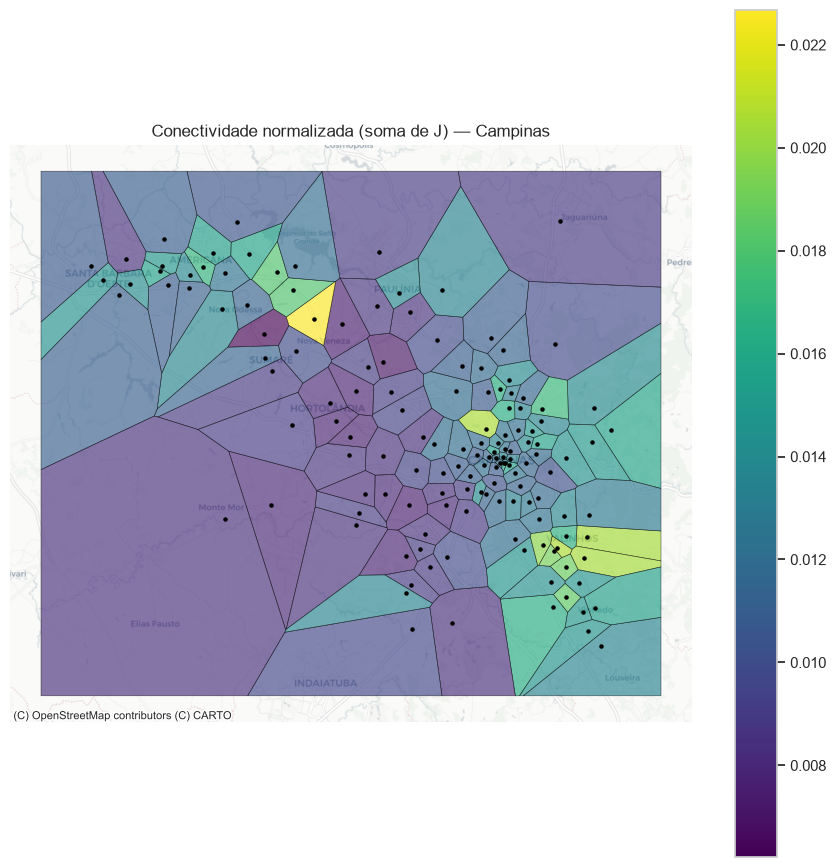

correlação de Spearman:
             forca_J  calls_total  n_users
forca_J        1.000       -0.479   -0.587
calls_total   -0.479        1.000    0.943
n_users       -0.587        0.943    1.000



,antenna_id,n_users,forca_J,calls_total,residence_quintile_state
98,5867,70,0.022677,8958,q4
140,8304,148,0.020661,7073,q5
17,1058,190,0.020560,29229,q5
90,5550,74,0.020450,2466,q5
73,4704,115,0.020444,4664,q5
108,6458,55,0.019748,2933,q5
130,7842,11,0.019159,730,q5
118,7064,46,0.018820,1420,q3


In [10]:
forca_J = Jz.sum(axis=1).rename("forca_J")
nodes["forca_J"] = nodes["antenna_id"].map(forca_J)

# vor foi montado antes desta coluna existir, então passamos a Series por `dados=`
mapa("forca_J", "Conectividade normalizada (soma de J) — " + config["city_name"],
     cmap="viridis", dados=forca_J)

print("correlação de Spearman:")
print(nodes[["forca_J", "calls_total", "n_users"]].corr(method="spearman").round(3).to_string())
print()
nodes.nlargest(8, "forca_J")[["antenna_id", "n_users", "forca_J", "calls_total",
                              "residence_quintile_state"]]

# Direção: quem liga para quem

**A matriz J do artigo é simétrica por definição**, e isso não é uma escolha de implementação:
*contato* é uma relação mútua. Se `i` e `j` se falaram, `j` também se falou com `i` — a equação
`K_lm = Σ_{i∈V_l} k_i(m)` dá exatamente o mesmo valor que `K_ml`.

O que **tem** direção é a **chamada**: quem discou. Duas medidas diferentes, então:

| | Simétrica? | O que mede |
|---|---|---|
| `K`, `J` (contatos) | sim, por definição | existe laço entre as duas regiões? |
| chamadas dirigidas | **não** | quem procura quem |

Esta seção monta a versão dirigida e mede a assimetria par a par. Note que isso é uma **extensão
além do artigo** — ele não trata de direção.

In [11]:
# matriz de chamadas dirigidas: linha = quem emite, coluna = quem recebe
ea = edges_antenna.dropna(subset=["emissor_antenna_id", "receptor_antenna_id"])
Cdir = (ea.pivot_table(index="emissor_antenna_id", columns="receptor_antenna_id",
                       values="q_calls", aggfunc="sum", fill_value=0)
          .reindex(index=ordem, columns=ordem, fill_value=0))

# contatos dirigidos: pares (i,j) distintos em que i ligou para j ao menos uma vez
pares_dir = ea[["id_emisor", "id_receiver", "emissor_antenna_id", "receptor_antenna_id"]].drop_duplicates()
Kdir = (pares_dir.groupby(["emissor_antenna_id", "receptor_antenna_id"]).size()
        .unstack(fill_value=0).reindex(index=ordem, columns=ordem, fill_value=0))

print(f"chamadas na matriz dirigida: {Cdir.to_numpy().sum():,}")
print(f"contatos dirigidos (pares ordenados): {Kdir.to_numpy().sum():,}")
print(f"K simétrica? {np.array_equal(K.to_numpy(), K.to_numpy().T)}  |  "
      f"Cdir simétrica? {np.array_equal(Cdir.to_numpy(), Cdir.to_numpy().T)}")

chamadas na matriz dirigida: 594,892
contatos dirigidos (pares ordenados): 48,947
K simétrica? True  |  Cdir simétrica? False


## Assimetria par a par

Para cada par de regiões, `(A→B − B→A) / (A→B + B→A)`: +1 significa que A só liga e nunca recebe,
−1 o contrário, 0 é equilíbrio perfeito.

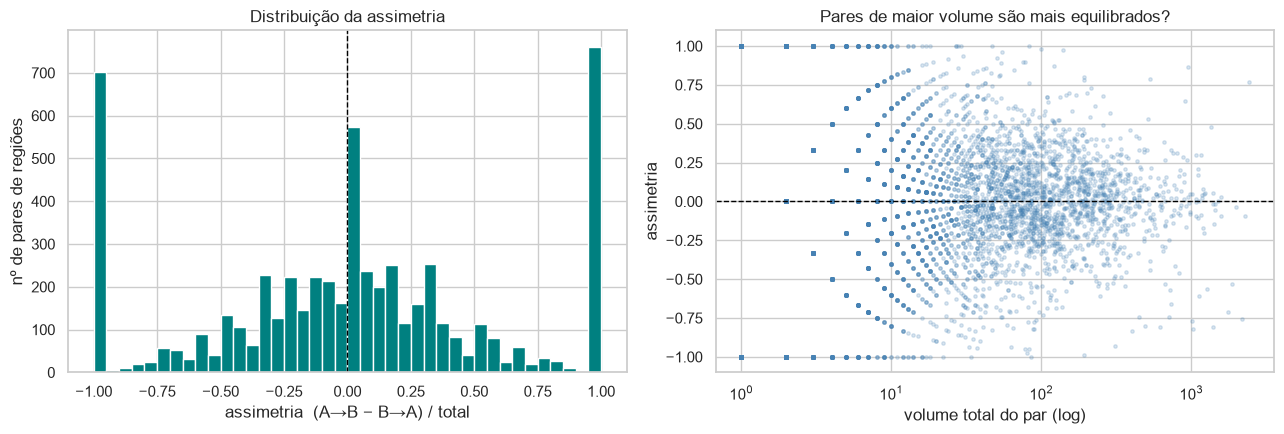

assimetria mediana (valor absoluto): 0.333
nos 25% de maior volume:             0.162
pares com assimetria > 0.5:          35.8%


In [12]:
Cn = Cdir.to_numpy().astype(float)
total = Cn + Cn.T
with np.errstate(invalid="ignore", divide="ignore"):
    A_sim = np.where(total > 0, (Cn - Cn.T) / total, np.nan)

li, mi = np.triu_indices(len(ordem), k=1)
assim = pd.DataFrame({
    "a": ordem[li], "b": ordem[mi],
    "a_para_b": Cn[li, mi], "b_para_a": Cn[mi, li],
    "assimetria": A_sim[li, mi],
}).dropna()
assim["total"] = assim["a_para_b"] + assim["b_para_a"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(assim["assimetria"], bins=40, color="teal")
axes[0].axvline(0, color="black", ls="--", lw=1)
axes[0].set_xlabel("assimetria  (A→B − B→A) / total")
axes[0].set_ylabel("nº de pares de regiões")
axes[0].set_title("Distribuição da assimetria")

fortes = assim[assim["total"] >= assim["total"].quantile(0.75)]
axes[1].scatter(assim["total"], assim["assimetria"], s=6, alpha=0.2, color="steelblue")
axes[1].axhline(0, color="black", ls="--", lw=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("volume total do par (log)"); axes[1].set_ylabel("assimetria")
axes[1].set_title("Pares de maior volume são mais equilibrados?")
plt.tight_layout(); plt.show()

print(f"assimetria mediana (valor absoluto): {assim['assimetria'].abs().median():.3f}")
print(f"nos 25% de maior volume:             {fortes['assimetria'].abs().median():.3f}")
print(f"pares com assimetria > 0.5:          {(assim['assimetria'].abs() > 0.5).mean():.1%}")

In [13]:
# os pares mais desequilibrados entre os de volume relevante
desq = fortes.reindex(fortes["assimetria"].abs().sort_values(ascending=False).index).head(10)
desq[["a", "b", "a_para_b", "b_para_a", "assimetria", "total"]].round(3)

,a,b,a_para_b,b_para_a,assimetria,total
6855,3974,4378,0.0,86.0,-1.000,86.0
3694,4192,5768,83.0,0.0,1.000,83.0
5627,6857,2467,1.0,193.0,-0.990,194.0
7176,4745,8304,98.0,1.0,0.980,99.0
5105,6197,4745,1.0,79.0,-0.975,80.0
80,22,393,138.0,2.0,0.971,140.0
923,1058,393,2.0,81.0,-0.952,83.0
4433,5028,4987,2.0,76.0,-0.949,78.0
5002,6165,4745,2.0,61.0,-0.937,63.0
9751,835,8309,11.0,297.0,-0.929,308.0


## No mapa: emissoras e receptoras

O balanço líquido por região já existe em `nodes["net_balance"]` — aqui ele no mapa, para ver se
emissoras e receptoras formam padrões territoriais.

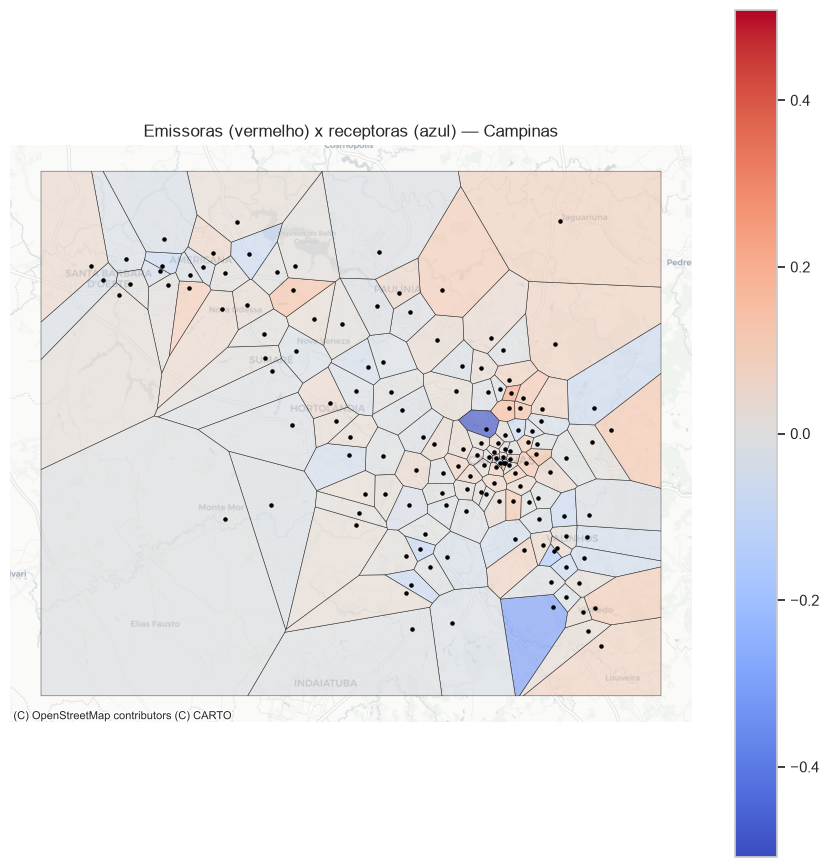

correlação de Spearman do balanço com:
net_balance    1.000
n_users       -0.109
calls_total   -0.075
insularity    -0.177


In [14]:
mapa("net_balance", "Emissoras (vermelho) x receptoras (azul) — " + config["city_name"],
     cmap="coolwarm", centro=0.0, dados=nodes.set_index("antenna_id")["net_balance"])

print("correlação de Spearman do balanço com:")
print(nodes[["net_balance", "n_users", "calls_total", "insularity"]].corr(method="spearman")
      .loc["net_balance"].round(3).to_string())

# Agrupamento hierárquico da matriz de correlação

Antes as antenas foram ordenadas pela partição do Louvain. Aqui deixamos os blocos **emergirem
sozinhos**: agrupamento hierárquico sobre a distância `1 − correlação`, sem informação nenhuma de
comunidade.

Se a estrutura que aparecer for parecida com a do Louvain, são dois métodos independentes
concordando.

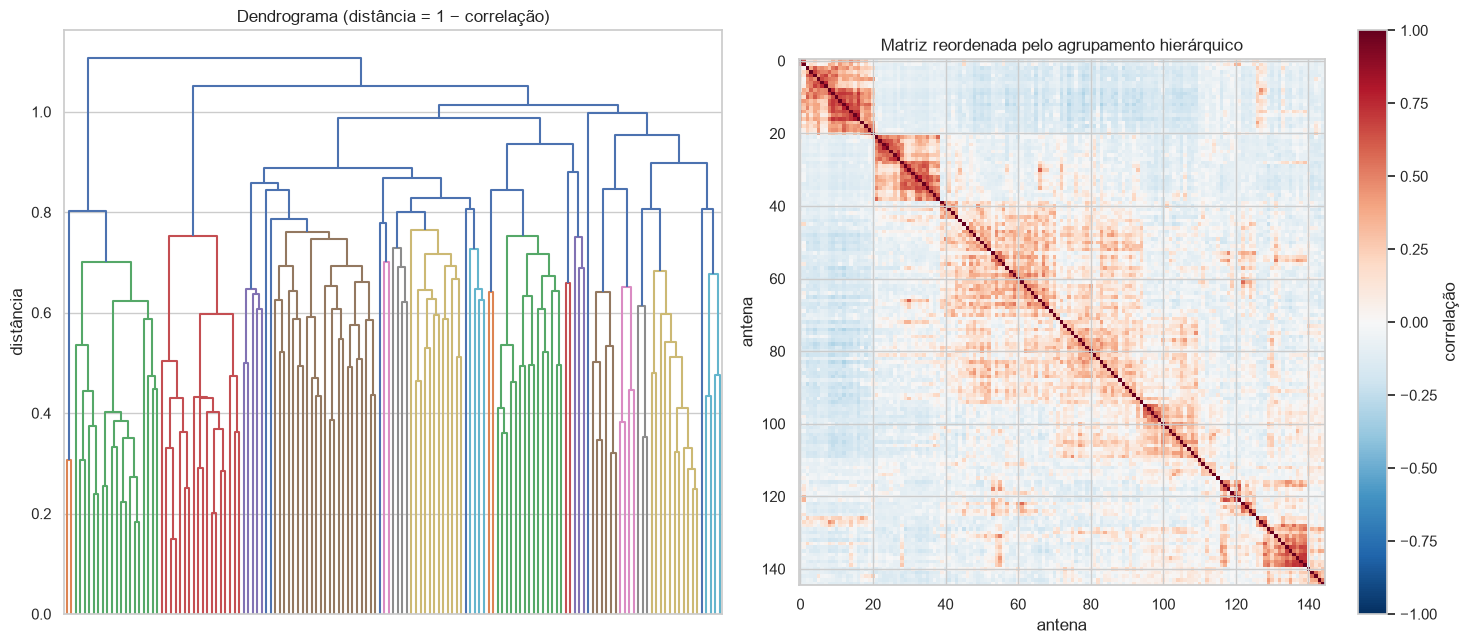

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

Dist = 1 - C.to_numpy()
np.fill_diagonal(Dist, 0.0)
Dist = (Dist + Dist.T) / 2                      # garante simetria exata
Z = linkage(squareform(Dist, checks=False), method="average")

ordem_h = ordem[dendrogram(Z, no_plot=True)["leaves"]]
Ch = C.reindex(index=ordem_h, columns=ordem_h)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
dendrogram(Z, ax=axes[0], no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
axes[0].set_title("Dendrograma (distância = 1 − correlação)")
axes[0].set_ylabel("distância")

im = axes[1].imshow(Ch.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
fig.colorbar(im, ax=axes[1], label="correlação")
axes[1].set_title("Matriz reordenada pelo agrupamento hierárquico")
axes[1].set_xlabel("antena"); axes[1].set_ylabel("antena")
plt.tight_layout(); plt.show()

In [16]:
def ari(a, b):
    """Adjusted Rand Index (sem sklearn)."""
    ct = pd.crosstab(a, b).to_numpy()
    c2 = lambda n: n * (n - 1) / 2
    idx, ea_, eb, n = c2(ct).sum(), c2(ct.sum(1)).sum(), c2(ct.sum(0)).sum(), c2(ct.sum())
    esp = ea_ * eb / n
    return (idx - esp) / ((ea_ + eb) / 2 - esp)


for k in [3, 4, 5, 6, 7]:
    grupos = pd.Series(fcluster(Z, k, criterion="maxclust"), index=ordem)
    print(f"k={k}: ARI com o Louvain = {ari(grupos.sort_index(), macro.sort_index()):.3f} | "
          f"tamanhos {sorted(grupos.value_counts().tolist(), reverse=True)}")

k=3: ARI com o Louvain = 0.378 | tamanhos [106, 21, 18]
k=4: ARI com o Louvain = 0.612 | tamanhos [76, 30, 21, 18]
k=5: ARI com o Louvain = 0.617 | tamanhos [76, 29, 21, 18, 1]
k=6: ARI com o Louvain = 0.847 | tamanhos [54, 29, 22, 21, 18, 1]
k=7: ARI com o Louvain = 0.819 | tamanhos [54, 22, 21, 19, 18, 10, 1]


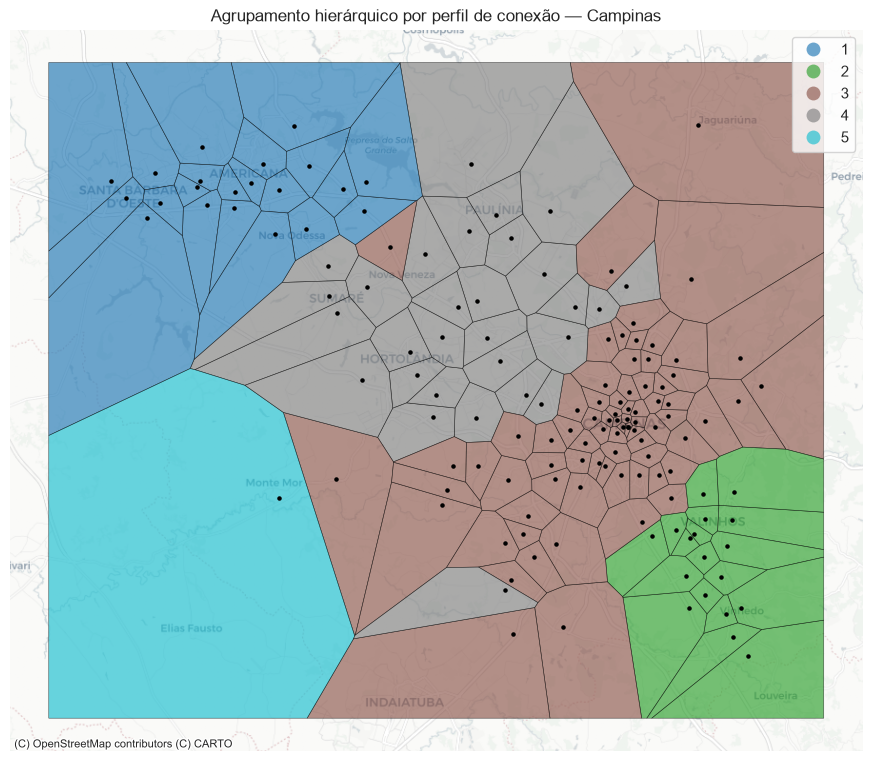

In [17]:
# a partição hierárquica de 5 grupos, no mapa — comparar com o mapa de macro-regiões do NB3
hier5 = pd.Series(fcluster(Z, 5, criterion="maxclust"), index=ordem).sort_index()
mapa("grupo_hier", "Agrupamento hierárquico por perfil de conexão — " + config["city_name"],
     cmap="tab10", categorico=True, dados=hier5)

# Comunidades detectadas direto sobre J

É o que o título do artigo sugere: *Detecting Communities from Cell Phone Antennas*. Comparamos três
pesos — volume de chamadas, contatos brutos e J normalizado.

In [18]:
from networkx.algorithms.community import modularity

particoes = {}
for w in ["weight", "n_pairs", "J"]:
    com = louvain_communities(G, weight=w, seed=42)
    particoes[w] = pd.Series({a: i for i, c in enumerate(com) for a in c}).sort_index()
    print(f"{w:8s} -> {len(com)} comunidades | Q={modularity(G, com, weight=w):.3f} | "
          f"tamanhos {sorted((len(c) for c in com), reverse=True)}")

print()
for x, y in [("weight", "J"), ("weight", "n_pairs"), ("n_pairs", "J")]:
    print(f"ARI {x} x {y}: {ari(particoes[x], particoes[y]):.3f}")
print(f"ARI J x hierárquico(5): {ari(particoes['J'], hier5):.3f}")

weight   -> 5 comunidades | Q=0.404 | tamanhos [54, 27, 25, 21, 18]
n_pairs  -> 5 comunidades | Q=0.316 | tamanhos [55, 27, 24, 21, 18]
J        -> 5 comunidades | Q=0.359 | tamanhos [48, 31, 27, 21, 18]

ARI weight x J: 0.528
ARI weight x n_pairs: 0.937
ARI n_pairs x J: 0.552
ARI J x hierárquico(5): 0.571


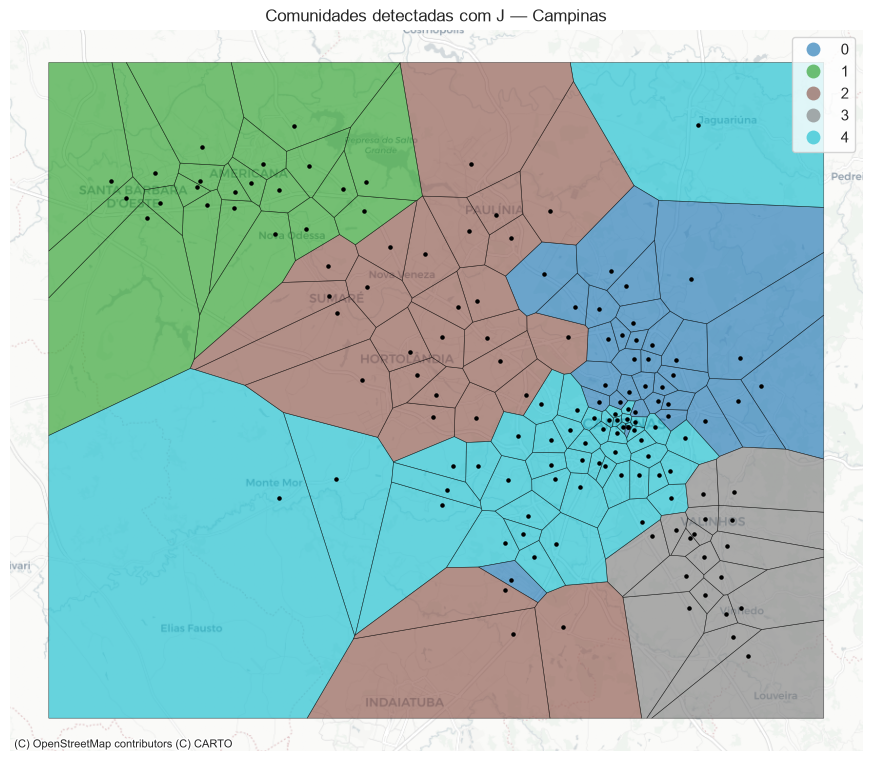

In [19]:
mapa("comunidade_J", "Comunidades detectadas com J — " + config["city_name"],
     cmap="tab10", categorico=True, dados=particoes["J"])

# A normalização de J é excessiva?

Na seção anterior a soma de J por região correlacionou **negativamente** com o tamanho (−0,59). A
suspeita: cada pessoa mantém um número limitado de contatos, então `K_lm` cresce mais ou menos
**linearmente** com a população, enquanto o denominador `u_l · u_m` cresce ao **quadrado** — J cairia
com o tamanho por construção, não por nada da cidade.

Teste: comparar três medidas de conectividade da mesma região.

| Medida | Fórmula | Normalização |
|---|---|---|
| volume | `Σ_m K_lm` | nenhuma |
| J | `Σ_m K_lm/(u_l·u_m)` | quadrática |
| contatos por morador | `Σ_m K_lm / u_l` | linear |

correlação de Spearman com o tamanho da região (n_users):
contatos_totais         0.969
forca_J                -0.587
contatos_por_morador   -0.246


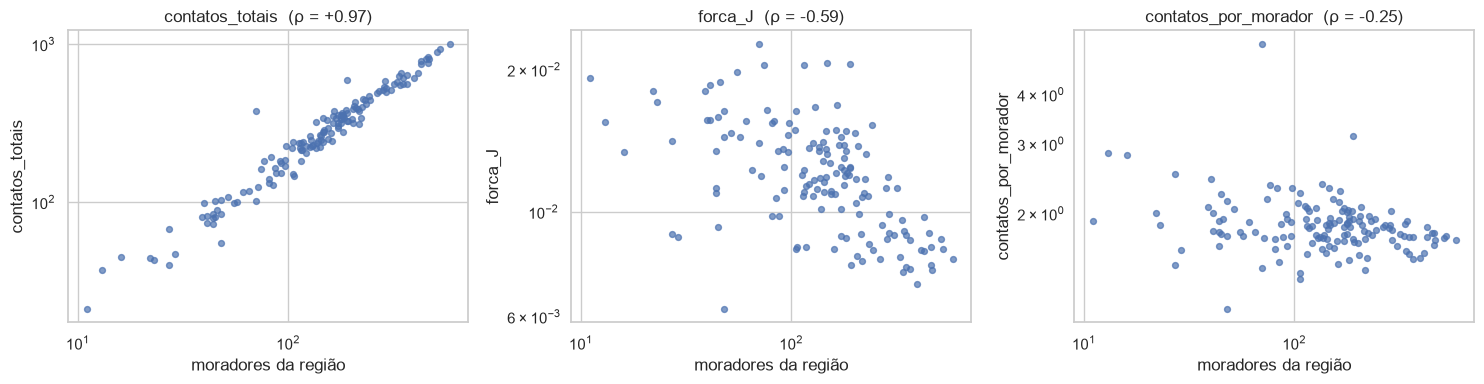

In [20]:
Kz = antenna.build_contact_matrix(edges_antenna, nodes, diagonal="zero").K
u = nodes.set_index("antenna_id")["n_users"]

medidas = pd.DataFrame({
    "contatos_totais": Kz.sum(axis=1),
    "forca_J": Jz.sum(axis=1),
    "contatos_por_morador": Kz.sum(axis=1) / u,
    "n_users": u,
})

print("correlação de Spearman com o tamanho da região (n_users):")
print(medidas.corr(method="spearman")["n_users"].drop("n_users").round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["contatos_totais", "forca_J", "contatos_por_morador"]):
    ax.scatter(medidas["n_users"], medidas[col], s=18, alpha=0.7)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("moradores da região"); ax.set_ylabel(col)
    rho = medidas[[col, "n_users"]].corr(method="spearman").iloc[0, 1]
    ax.set_title(f"{col}  (ρ = {rho:+.2f})")
plt.tight_layout(); plt.show()

Se `contatos_por_morador` ficar sem correlação com o tamanho enquanto `forca_J` fica fortemente
negativa, está confirmado: a normalização quadrática de J é excessiva para comparar **regiões**.

Isso não invalida J como medida de **ligação entre um par** — que é para o que o artigo o define. Só
significa que somar J por linha não é uma boa medida de conectividade de uma região.